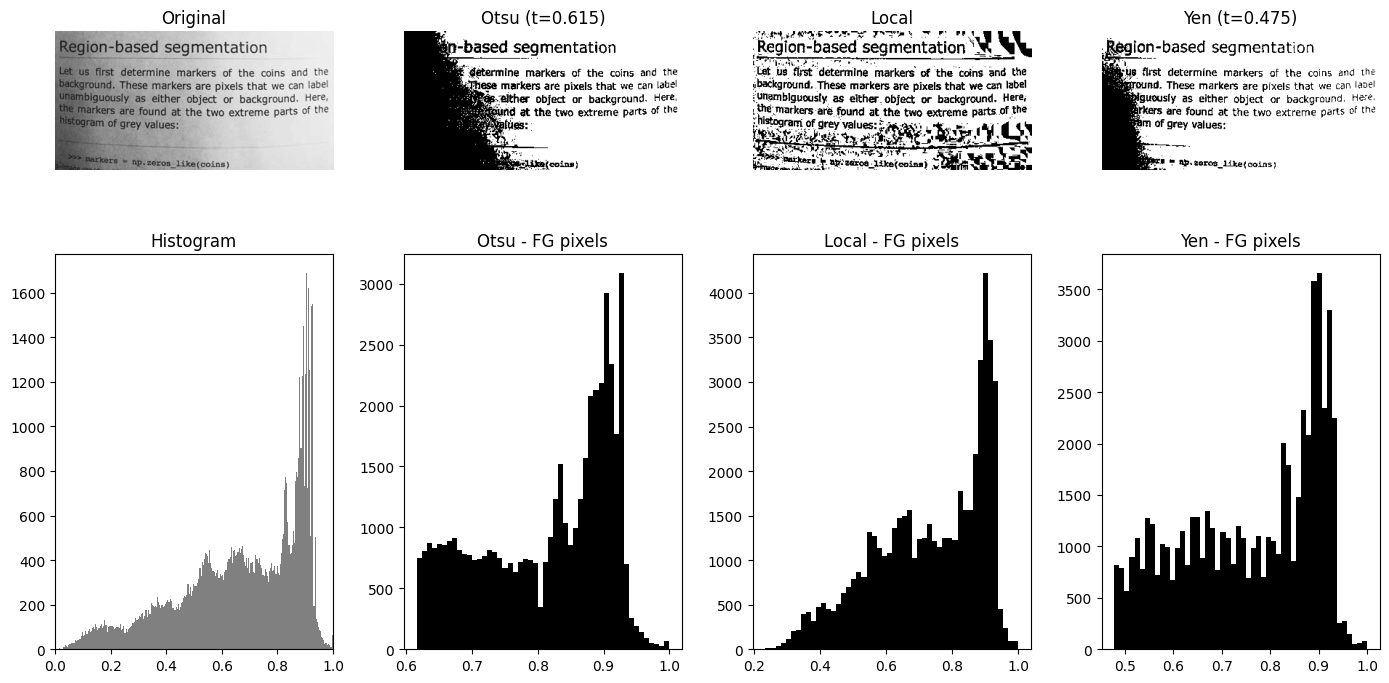

Otsu threshold: 0.6152, Yen: 0.4746
Catatan: Otsu cocok jika histogram dua-puncak; local lebih baik jika pencahayaan tidak seragam.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_float

# Siapkan citra
img = img_as_float(data.page())

# Otsu
thr_otsu = filters.threshold_otsu(img)
bw_otsu = img > thr_otsu

# Local (adaptive)
thr_local = filters.threshold_local(img, block_size=35)
bw_local = img > thr_local

# Yen
thr_yen = filters.threshold_yen(img)
bw_yen = img > thr_yen

# Visualisasi
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes[0,0].imshow(img, cmap='gray')
axes[0,0].set_title('Original')
axes[0,0].axis('off')

axes[0,1].imshow(bw_otsu, cmap='gray')
axes[0,1].set_title(f'Otsu (t={thr_otsu:.3f})')
axes[0,1].axis('off')

axes[0,2].imshow(bw_local, cmap='gray')
axes[0,2].set_title('Local')
axes[0,2].axis('off')

axes[0,3].imshow(bw_yen, cmap='gray')
axes[0,3].set_title(f'Yen (t={thr_yen:.3f})')
axes[0,3].axis('off')

axes[1,0].hist(img.ravel(), bins=256, range=(0,1), color='gray')
axes[1,0].set_title('Histogram')
axes[1,0].set_xlim(0,1)

axes[1,1].hist(img[bw_otsu].ravel(), bins=50, color='black')
axes[1,1].set_title('Otsu - FG pixels')

axes[1,2].hist(img[bw_local].ravel(), bins=50, color='black')
axes[1,2].set_title('Local - FG pixels')

axes[1,3].hist(img[bw_yen].ravel(), bins=50, color='black')
axes[1,3].set_title('Yen - FG pixels')

plt.tight_layout()
plt.show()

print(f'Otsu threshold: {thr_otsu:.4f}, Yen: {thr_yen:.4f}')
print('Catatan: Otsu cocok jika histogram dua-puncak; local lebih baik jika pencahayaan tidak seragam.')